In [1]:
const c_s = 2.99798458E8
const ħ = 1.054571E-34
const kb = 1.3806452E-23
const ϵ0 =  8.85418E-12
const q_c = 1.60217663e-19
const m_e = 9.11e-31
const μB = 1.39962449361e10

1.39962449361e10

In [2]:
module utils
using LinearAlgebra
using Random
using Statistics
using Distributions


export pol_v, decompose_spherical, project_onto_vector, project_onto_plane, rotation_matrix, get_angle, getSphereVec


const pol_v = Dict("sigma_p" => -1 / sqrt(2) * ComplexF64[1, 1im, 0], "sigma_m" => 1 / sqrt(2) * ComplexF64[1, -1im, 0], "pi" => ComplexF64[0, 0, 1])




function decompose_spherical(pol)
   return ComplexF64[dot(conj(pol_v["pi"]), pol), dot(conj(pol_v["sigma_p"]), pol), dot(conj(pol_v["sigma_m"]), pol)]
end


project_onto_vector(v, n) = dot(v, n / norm(n)) * (n / norm(n))
project_onto_plane(x, n) = x - dot(x, n / norm(n)) * (n / norm(n))




function rotation_matrix(axis, theta)
   axis = axis / norm(axis)
   a = cos(theta / 2)
   b, c, d = -axis * sin(theta / 2)
   return [a*a+b*b-c*c-d*d 2*(b*c-a*d) 2*(b*d+a*c)
       2*(b*c+a*d) a*a+c*c-b*b-d*d 2*(c*d-a*b)
       2*(b*d-a*c) 2*(c*d+a*b) a*a+d*d-b*b-c*c]
end


get_angle(v1, v2) = acos(dot(v1, v2) / (norm(v1) * norm(v2)))


function getSphereVec(n)
   uvec = rand(Normal(), n)
   uvec = uvec / norm(uvec)
   return uvec
end


end

module BeamClass
using ..utils
using LinearAlgebra
export BeamProperties, GaussianBeam, get_Intensity


struct BeamProperties{T}
   Loc::T
   dir::T
   pol
   waist::Float64
   zr::Float64
end


#BeamProperties(Loc::T, dir::T, pol) where {T} = BeamProperties{T}(Loc, dir, pol, 1e10, 1e10)
BeamProperties(Loc::T, dir::T, waist::Float64, wavelength::Float64) where T = BeamProperties{T}(Loc, dir, pol_v["pi"], waist, pi * waist^2 / wavelength)




mutable struct GaussianBeam
   beamStruct::BeamProperties
   I0::Float64
end


function get_Intensity(Beam::GaussianBeam, pos)
   BP = Beam.beamStruct
   r = norm(project_onto_plane(pos- BP.Loc, BP.dir))
   z = norm(project_onto_vector(pos- BP.Loc, BP.dir))
   w(z_i) = BP.waist * sqrt(1 + (z_i / BP.zr)^2)
   I = Beam.I0 * (BP.waist / w(z))^2 * exp(-2 * r^2 / (w(r)^2))
   return I
end


end

Main.BeamClass

In [3]:
using ..BeamClass
using ..utils


wL = 1064e-9

H_Loc_1::Vector{Float64} = [0, 0, 0]
H_Loc_2::Vector{Float64} = [0, 0, -7.5e-6]
H_Loc_3::Vector{Float64} = [0, 0, 7.5e-6]
V_Loc::Vector{Float64} = [0, 0, 0]
BeamPropComb = [BeamProperties(H_Loc_1, [0.0, 1.0, 0.0], 30e-6, wL), BeamProperties(H_Loc_2, [0.0, 1.0, 0.0], 7e-6, wL), BeamProperties(H_Loc_3, [0.0, 1.0, 0.0], 7e-6, wL), BeamProperties(V_Loc, [0.0, -sin(70*pi/180), cos(70*pi/180)], 100e-6, wL)]
BeamComb::Vector{GaussianBeam} = [GaussianBeam(BeamPropComb[1], 1.0), GaussianBeam(BeamPropComb[2], 1.0), GaussianBeam(BeamPropComb[3], 1.0), GaussianBeam(BeamPropComb[4], 1.0)]


4-element Vector{GaussianBeam}:
 GaussianBeam(BeamProperties{Vector{Float64}}([0.0, 0.0, 0.0], [0.0, 1.0, 0.0], ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im], 3.0e-5, 0.002657362206983847), 1.0)
 GaussianBeam(BeamProperties{Vector{Float64}}([0.0, 0.0, -7.5e-6], [0.0, 1.0, 0.0], ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im], 7.0e-6, 0.00014467860904689836), 1.0)
 GaussianBeam(BeamProperties{Vector{Float64}}([0.0, 0.0, 7.5e-6], [0.0, 1.0, 0.0], ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im], 7.0e-6, 0.00014467860904689836), 1.0)
 GaussianBeam(BeamProperties{Vector{Float64}}([0.0, 0.0, 0.0], [0.0, -0.9396926207859083, 0.3420201433256688], ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im], 0.0001, 0.029526246744264968), 1.0)

## Potential Check

In [4]:
using PhysicalConstants.CODATA2018
# Constants
h = PlanckConstant.val
function getPotential(x, y, z, Intensity::Vector{Float64}, BeamComb)
    polarizibility = 5.53e-5 * 1e6 * h *1e-4

    pos::Vector{Float64} = [x, y, z]
    totalIntensity = 0
    
    for (beam, beamIntensity) in enumerate(Intensity)
        
        totalIntensity += beamIntensity*get_Intensity(BeamComb[beam], pos)
    end
    -polarizibility*totalIntensity
end

getPotential (generic function with 1 method)

In [5]:
getIntensity::Vector{Float64} = [0, 10, 10, 10]*1e7
Potential(x, y, z) = getPotential(x, y, z, getIntensity, BeamComb)
Potential(x, y, z, Intensity::Vector{Float64}) = getPotential(x, y, z, Intensity, BeamComb)
Potential(pos) = getPotential(pos..., getIntensity, BeamComb)
Potential(pos, Intensity::Vector{Float64}) = getPotential(pos..., Intensity, BeamComb)

Potential (generic function with 4 methods)

In [337]:
getIntensity::Vector{Float64} = [0, 30, 30, 10]*1e7
Potential(x, y, z) = getPotential(x, y, z, getIntensity, BeamComb)
Potential(x, y, z, Intensity::Vector{Float64}) = getPotential(x, y, z, Intensity, BeamComb)
Potential(pos) = getPotential(pos..., getIntensity, BeamComb)
Potential(pos, Intensity::Vector{Float64}) = getPotential(pos..., Intensity, BeamComb)
z = -25e-6:1e-8:25e-6
x = 0.0
y = 0.0
pz = [Potential(0, 0, z_i) for z_i in z];

In [8]:
using Plots

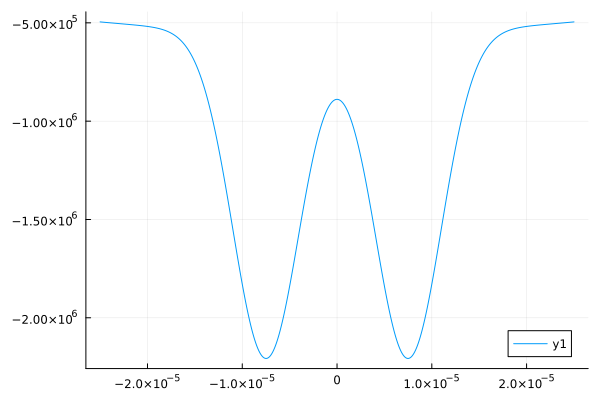

In [338]:
plot(z, pz/h)

In [ ]:
initCond

## MC Transfer

In [318]:

using Random
using Distributions
moleculeMass = (40 + 87)*1.66054E-27
const kb = 1.3806452E-23
function set_SystemRHS(Pot, rampFunc; dl = 1e-8, I0 = [10.0, 0, 0, 10.0]*1e7, RampTime  = rampTime, FInt = 30) 
    finalInt = FInt
    function RHS(dy, y, p, t)
        I::Vector{Float64} = I0 .+ ([-1, finalInt/10, finalInt/10, 0]*rampFunc(t, RampTime))*1e7
        x, y_, z = y[1:3]
        dy[1:3] = y[4:6]
        dy[4:6] = -([Pot(x + dl, y_, z, I) - Pot(x, y_, z, I), Pot(x, y_ + dl, z, I) - Pot(x, y_, z, I), Pot(x, y_, z + dl, I) - Pot(x, y_, z , I)]/dl)*1/moleculeMass

        y[7] =   1/2*moleculeMass*sum(abs2.(y[4:6])) + Pot(x, y_, z, I)# + 1/2*moleculeMass*sum(abs2.(y[4:6]))
        y[8] =   1/2*moleculeMass*sum(abs2.(y[4:6])) #+ Pot(x, y_, z, I)# + 1/2*moleculeMass*sum(abs2.(y[4:6]))
        dy[7:8] .= 0
    end
    return RHS
 end

function sampleVelocities_BD(Temp, atomNum)
    scale = sqrt(kb * Temp /moleculeMass)
    vx, vy, vz = randn(atomNum) * scale, randn(atomNum) * scale, randn(atomNum) * scale
    velList = []
    for i in 1:atomNum
        push!(velList, [vx[i], vy[i], vz[i]])
    end
    return velList
end
function sampleVelocities_BD(Temp, atomNum, rng)
    scale = sqrt(kb * Temp /moleculeMass)
    vx, vy, vz = randn(rng, atomNum) * scale, randn(rng, atomNum) * scale, randn(rng, atomNum) * scale
    velList = []
    for i in 1:atomNum
        push!(velList, [vx[i], vy[i], vz[i]])
    end
    return velList
end
function generateAtoms(RBeam::T,ZBeam::T,  Temp, atomNum; Intensity = [10.0, 0.0, 0.0, 10.0]*1e7,  edims = 0 ) where {T<:GaussianBeam}
    coordList = []
 

    trapR = sqrt(8*(1/2*pi * Intensity[1]*RBeam.beamStruct.waist^2)/(pi*moleculeMass*RBeam.beamStruct.waist^4))
    trapZ = sqrt(8*(1/2*pi * Intensity[4]*ZBeam.beamStruct.waist^2)/(pi*moleculeMass*ZBeam.beamStruct.waist^4))

    sigmaR = 1 /trapR * sqrt(kb * Temp / moleculeMass)
    sigmaZ = 1 / trapZ * sqrt(kb * Temp / moleculeMass)
    coordZ = rand(Normal(0, sigmaZ), atomNum)
    coordR = rand(Normal(0, sigmaR), atomNum)

    velDist = sampleVelocities_BD(Temp, atomNum)
    
    for i in 1:atomNum
        x, z = coordR[i] * getSphereVec(2)
        y = coordZ[i]
        coord = [x, y, z, velDist[i]..., zeros(Float64, edims)...]

 
        push!(coordList, coord )
    end
    return coordList
 end
 

function generateAtomsREJ(Potential, range, temp, atomNum; Intensity = [10.0, 0.0, 0.0, 10.0]*1e7, edims = 0 )
    coordList = []
    while length(coordList) < atomNum
        coordZ = [rand(Uniform(-range[1], range[1]), 1)[1], rand(Uniform(-range[2], range[2]), 1)[1], rand(Uniform(-range[3], range[3]), 1)[1]] 
        vel_c = sampleVelocities_BD(temp, 1)[1]
        E = 1/2*moleculeMass*sum(abs2.(vel_c)) + (Potential(coordZ..., Intensity) - Potential([0.0, 0.0, 0.0]..., Intensity))
        if exp(-E/(kb*temp)) > rand()
            #println(E/(kb*temp))
            push!(coordList, [coordZ...,vel_c..., zeros(Float64, edims)...])
        end
    end
    coordList
end

using Random, Distributions, Base.Threads

function generateAtomsREJ_P(Potential, range, temp, atomNum; Intensity = [10.0, 0.0, 0.0, 10.0]*1e7, edims = 0 )
    coordList = Vector{Any}[]
    lockit = ReentrantLock()

    @threads for _ in 1:atomNum
        localCoordList = []
        rng = MersenneTwister(Int(floor((rand(Uniform(1, 1e7))))))

        while length(localCoordList) < 1
            coordZ = [rand(rng, Uniform(-range[1], range[1])), rand(rng, Uniform(-range[2], range[2])), rand(rng, Uniform(-range[3], range[3]))] 
            vel_c = sampleVelocities_BD(temp, 1, rng)[1]
            E = 1/2*moleculeMass*sum(abs2.(vel_c)) + (Potential(coordZ..., Intensity) - Potential([0.0, 0.0, 0.0]..., Intensity))

            if exp(-E/(kb*temp)) > rand(rng)
                push!(localCoordList, [coordZ...,vel_c..., zeros(Float64, edims)...])
            end
        end

        lock(lockit) do
            append!(coordList, localCoordList)
        end
    end

    coordList
end


generateAtomsREJ_P (generic function with 1 method)

In [319]:
rangeSpawn = [200e-6, 30e-6, 30e-6]
initCond = generateAtomsREJ_P(Potential, rangeSpawn, 500e-9, 2000, edims = 2);

In [12]:
using GLMakie

In [13]:
initMat = hcat(initCond...)

7×2000 Matrix{Float64}:
 -5.1918e-7    -2.24917e-6    2.6045e-6    …  -1.80451e-6   -3.57703e-7
  4.77163e-6    2.79695e-5   -6.87137e-6       5.91574e-6    1.12135e-5
 -2.19942e-8    3.19641e-7   -1.09794e-6      -8.97e-7      -1.40004e-8
 -0.0051074     0.0053989     0.00645834      -0.00324984    0.00475981
 -0.00558352   -0.00299596    0.00441035       0.000306173  -0.00673174
  0.000365256  -0.000375226  -0.000781769  …   2.90616e-5    0.00243397
  0.0           0.0           0.0              0.0           0.0

In [39]:
using GLMakie
f = Figure()
hist(f[1, 1], vec(initMat[1, :]), bins = 100)
f

In [29]:
#data = randn(1000)
hist(f[1, 3], data,  bins = 10)
f

In [ ]:
s

In [14]:
using DifferentialEquations

In [1]:
initCond = generateAtoms(BeamComb[1], BeamComb[4], 500e-9, 10, edims= 1)#reshape(vcat(generateAtoms(BeamComb[1], BeamComb[4], 500e-9, 10)... , zeros(Float64, 10)),(10, 7)) 

UndefVarError: UndefVarError: BeamComb not defined

In [6]:
using Base.Threads

In [55]:
findall([0, 0.1, 0.3] .> 3)

Int64[]

In [265]:

function simulate(initCond, rampTime, rampProfile; Fend = 30)
    n = size(initCond, 1)
    #println(n)
    DE = Vector{Any}(undef, n)
    FinalInt = Fend
    @threads for i in 1:n
        atom::Vector{Float64} = initCond[i]
        RHS = set_SystemRHS(Potential, rampProfile, RampTime = rampTime, FInt = FinalInt)
        
        tend = rampTime + 1e-3#FinalInt*1e7/rampSpeed > 20e-3 ? FinalInt*1e7/rampSpeed : 10e-3
        dt = 1e-8
        prob = ODEProblem(RHS, hcat(atom...), (0.0, tend))
        sol = solve(prob, Tsit5(), dt=dt, adaptive=true)
        
        DE[i] = [sol.t[sol.t .> rampTime], sol.u[sol.t .> rampTime]] # Adjust as per your requirement
    end
    DE#[i]
end


function simulateSanity(initCond)
    DKE = []
    rampSpeed = 1e-9
    for (i, atom) in enumerate(initCond)
        RHS = set_SystemRHS(Potential, RampRate = rampSpeed)
        
        tend = 20e-3
        dt = tend/1e5
        prob = ODEProblem(RHS, atom, tend)
        
        sol = solve(prob, Tsit5(), dt=dt, adaptive=true)
        
        push!(DKE, [sol.t, sol.u, 1/2*moleculeMass*(sum(sol.u[end][4:6].^2))])#
        #1/2*moleculeMass*(sum(sol.u[end][4:6].^2) - sum(sol.u[1][4:6].^2)) + (Potential(sol.u[end][1:3], ) -  Potential(atom[1:3], [10.0, 0.0, 0.0, 10.0]))
    end
    DKE
end


simulateSanity (generic function with 1 method)

In [215]:
tramp = [[1:10:100...]*1e-6... [0.1:0.1:1...]*1e-3... [0.1:0.1:0.5...]...]

1×30 Matrix{Float64}:
 1.0e-6  1.1e-5  2.1e-5  3.1e-5  4.1e-5  …  0.4  0.5  0.6  0.7  0.8  0.9  1.0

In [258]:
tramp2 = [[1:10:100...]*1e-6... [0.1:0.1:1...]*1e-3... [1:10:250...]*1e-3...]

1×45 Matrix{Float64}:
 1.0e-6  1.1e-5  2.1e-5  3.1e-5  4.1e-5  …  0.201  0.211  0.221  0.231  0.241

In [264]:
tramp3 = [[1:10:100...]*1e-6... [0.1:0.01:1...]*1e-3... [1:10:100...]*1e-3...]

1×111 Matrix{Float64}:
 1.0e-6  1.1e-5  2.1e-5  3.1e-5  4.1e-5  …  0.051  0.061  0.071  0.081  0.091

In [219]:
ans = [simulate(initCond, t_end, rampFuncLin; Fend = 20) for t_end in tramp];

2000


2000


2000


2000


2000


...

2000


2000


2000


2000


2000


In [261]:
ans_C = [simulate(initCond, t_end, rampFuncLin; Fend = 20) for t_end in tramp2];

2000


2000


2000


2000


2000


...

2000


2000


2000


2000


2000


In [266]:
ans_CC = [simulate(initCond, t_end, rampFuncLin; Fend = 20) for t_end in tramp3];

In [323]:
function analyze(ans_T, inten)
    polarizibility = 5.53e-5 * 1e6 * h *1e-4

    numOfAtoms = length(ans_T)
    Temp = zeros(Float64, numOfAtoms)
    Energy = zeros(Float64, numOfAtoms)
    Intensity = zeros(Float64, numOfAtoms)
    TrapDepth = zeros(Float64, numOfAtoms)
    
    for atom in 1:numOfAtoms
        t_array = ans_T[atom][1]
        sol = vcat(ans_T[atom][2]...)
        Energy[atom] =mean(sol[:, 7])/kb*1e6
        Temp[atom] = mean(sol[:, 8])/kb*1e6
        Intensity[atom] = Potential(sol[end, 1:3]..., inten)/polarizibility*1e-7
        TrapDepth[atom] = Potential(sol[end, 1:3]..., inten)/kb*1e6
    end
   [mean(Energy), mean(Temp), mean(Intensity), std(Intensity), mean(TrapDepth), std(TrapDepth)]
end


analyze (generic function with 2 methods)

In [345]:
simulate(initCond, 10e-3, rampFuncLin; Fend = 20)

2000-element Vector{Any}:
 Vector[[0.010043895810336791, 0.010097654399893411, 0.01016027340413319, 0.010224156310104487, 0.010281624495317828, 0.010341626048412607, 0.010404422966415285, 0.01046499761266361, 0.010521680339144298, 0.010580556892725274, 0.010646437024111664, 0.010700496754941393, 0.01076341385308718, 0.010826875213240864, 0.010883888204753892, 0.010944514975539894, 0.011], [[1.733019469217654e-6 1.4661221408688012e-5 … -9.308268332712752e-28 5.944531839452173e-29], [2.1951049681847656e-6 1.428817772705353e-5 … -9.31084702700081e-28 3.019626887628898e-29], [9.822648583451904e-7 1.3841417913493327e-5 … -9.310371771429816e-28 1.2026975578904117e-28], [-1.1710715844514704e-6 1.337035714728428e-5 … -9.305163601555232e-28 1.016680036280549e-28], [-2.2200321648633736e-6 1.2934068180804791e-5 … -9.302674732693977e-28 2.763904733588612e-29], [-1.6021489260325029e-6 1.2468133148556566e-5 … -9.301830650773694e-28 8.371682819025133e-29], [4.308041049626912e-7 1.196940331240987e-5 …

In [341]:
function analyzeSplit(ans_T, inten)
    polarizibility = 5.53e-5 * 1e6 * h *1e-4

    numOfAtoms = length(ans_T)
    Temp = zeros(Float64, numOfAtoms)
    Energy = zeros(Float64, numOfAtoms)
    Intensity =Vector{Vector{Float64}}(undef, numOfAtoms )# zeros(Vector{Float64}, numOfAtoms)
    TrapDepth = zeros(Float64, numOfAtoms)
    
    for atom in 1:numOfAtoms
        t_array = ans_T[atom][1]
        sol = vcat(ans_T[atom][2]...)
        Energy[atom] =mean(sol[:, 7])/kb*1e6
        Temp[atom] = mean(sol[:, 8])/kb*1e6
        Intensity[atom] = [sol[end, 3] > 0.0, Potential(sol[end, 1:3]..., inten)/polarizibility*1e-7]
        TrapDepth[atom] = Potential(sol[end, 1:3]..., inten)/kb*1e6
    end
    Intensity #[mean(Energy), mean(Temp), mean(Intensity), std(Intensity), mean(TrapDepth), std(TrapDepth)]
end


analyzeSplit (generic function with 1 method)

In [298]:
function analyze_(initCond)
    polarizibility = 5.53e-5 * 1e6 * h *1e-4

    numOfAtoms = length(initCond)
    Intensity = zeros(Float64, numOfAtoms)

    for atom in 1:numOfAtoms
        Intensity[atom] = Potential(initCond[atom][1:3]..., [10e7, 0, 0, 10e7])/polarizibility*1e-7
    end
    [mean(Intensity), std(Intensity)]
end


analyze_ (generic function with 1 method)

In [299]:
analyze_(initCond)

2-element Vector{Float64}:
 -19.75358567565219
   0.20296724893967943

In [238]:
analyzedTemp = [analyze(ans[ind]) for ind in 1:length(tramp)]
analyzedVec = hcat(analyzedTemp...)

2×30 Matrix{Float64}:
 -40.1294  -40.1406  -40.1605  -40.1937  …  -75.4458   -75.3885   -75.3355
  11.2029   12.1141   12.4768   12.7281       1.97985    2.00536    2.02556

In [262]:
analyzedTemp_2 = [analyze(ans_C[ind]) for ind in 1:length(tramp2)]
analyzedVec_2 = hcat(analyzedTemp_2...)

2×45 Matrix{Float64}:
 -40.1294  -40.1406  -40.1605  -40.1937  …  -75.6894   -75.6828   -75.6986
  11.2029   12.1141   12.4768   12.7281       1.86469    1.85784    1.86402

In [295]:
analyze(ans_C[argmin(abs.(tramp2 .- 100e-3))[2]])

6-element Vector{Float64}:
 -75.49689486774392
   1.987670412061179
 -29.20030257521673
   0.5006441748680573
 -77.49727377846985
   1.3287039949468065

In [324]:
res10 = simulate(initCond, 100e-3, rampFuncLin; Fend = 10)

2000-element Vector{Any}:
 Vector[[0.10001059596746167, 0.10009549376407728, 0.10018004841076776, 0.10025979917233459, 0.1003461566348223, 0.10042959433964342, 0.10051244911362697, 0.10059836182480279, 0.10068307184013191, 0.1007682460047678, 0.10085114515070927, 0.1009363311513555, 0.101], [[-1.2589393301796405e-6 -1.448306730972312e-5 … -6.527530471898408e-28 5.115616418740484e-29], [5.416146983529572e-8 -1.5127601361805248e-5 … -6.530847300587998e-28 4.367660154675631e-29], [1.3247401059482086e-6 -1.5758884917781302e-5 … -6.532593964820812e-28 2.667346841424234e-29], [1.5330119729512036e-6 -1.634404310327534e-5 … -6.5313962834425965e-28 4.142957753880069e-29], [4.628599623388519e-7 -1.6963050037475526e-5 … -6.5282553693361865e-28 5.084534279894762e-29], [-9.898300048242967e-7 -1.75435176480936e-5 … -6.526374583413477e-28 2.967432542333535e-29], [-1.6589442920285618e-6 -1.8102302769449845e-5 … -6.526805068802506e-28 3.102358689877306e-29], [-9.67183113604149e-7 -1.866355569964388e-5 

In [342]:
Inten10 = analyzeSplit(res10, [0, 10e7, 10e7, 10e7])

2000-element Vector{Vector{Float64}}:
 [1.0, -18.582395424643504]
 [1.0, -19.650127995083132]
 [1.0, -19.818370267363363]
 [1.0, -18.568483351770148]
 [1.0, -19.16801796638336]
 [0.0, -19.651185159533537]
 [0.0, -19.61404633735388]
 [0.0, -19.82199786329281]
 [1.0, -19.105113971057474]
 [1.0, -19.256264098591924]
 ⋮
 [1.0, -19.50048207959656]
 [1.0, -19.5431796413114]
 [1.0, -19.77234181924285]
 [1.0, -19.64708927407093]
 [0.0, -19.49362949742756]
 [0.0, -19.49458415831106]
 [1.0, -19.22458316644807]
 [0.0, -19.326351282951276]
 [0.0, -19.690289860561496]

In [343]:
using JLD2

save_object("intensityDist10.jld2", Inten10)

In [316]:
analyze(simulate(initCond, 20e-3, rampFuncConst; Fend = 20), [5e7, 0, 0, 10e7])

6-element Vector{Float64}:
 -38.78618611273488
   0.5177668138294903
 -14.798871407582242
   0.15283020363512514
 -39.27603784692146
   0.40560963716803833

In [304]:
res5 = simulate(initCond, 100e-3, rampFuncLin; Fend = 5)

2000-element Vector{Any}:
 Vector[[0.10000013208325548, 0.10012582824319347, 0.10024060921411355, 0.10035793652468186, 0.10048799582122386, 0.10059977809257735, 0.10072414052630771, 0.1008477847057831, 0.10096316323739139, 0.101], [[1.5896862724847925e-7 5.29522240439201e-6 … -5.023507699776776e-28 3.58121869995824e-29], [1.8090123912625026e-6 4.336198605739024e-6 … -5.024600358025355e-28 1.8589712101762164e-29], [1.882469604169496e-6 3.428320233196499e-6 … -5.02421291818544e-28 1.4131746981305763e-29], [4.970633598034558e-7 2.472977757072148e-6 … -5.02321291955593e-28 3.3694995741640946e-29], [-1.4488436861960433e-6 1.3845958804385517e-6 … -5.022461280133787e-28 2.7326866225318166e-29], [-2.015786923732154e-6 4.2498838771767357e-7 … -5.022892356535196e-28 1.3408040529375077e-29], [-9.68667924243029e-7 -6.692740188811381e-7 … -5.023755730904797e-28 2.931168942071152e-29], [9.447675682541554e-7 -1.7839715160288313e-6 … -5.024676790889103e-28 3.5282534753656173e-29], [1.962960500677501e-

In [303]:
analyze(res5, 5)

6-element Vector{Float64}:
 -37.78523179675317
   0.9211616758741434
 -14.585969969676377
   0.25464373738863344
 -38.71099983134884
   0.6758216077229546

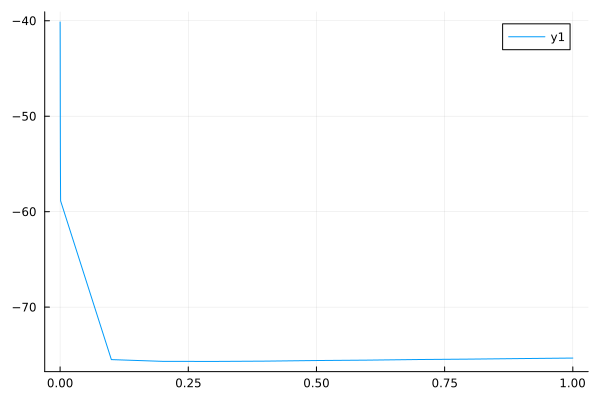

In [247]:
plot(vec(tramp), analyzedVec[2, :])
plot(vec(tramp), analyzedVec[1, :])

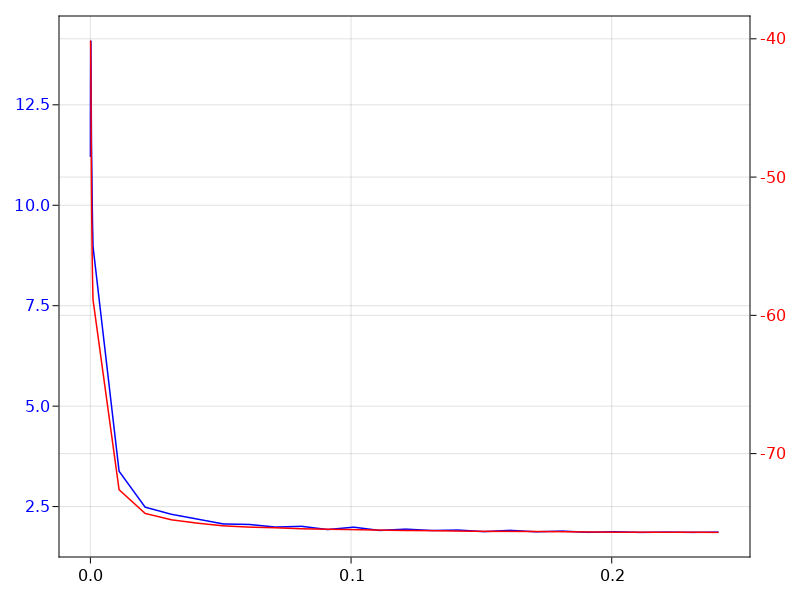

In [263]:
using CairoMakie

f = Figure()

ax1 = Axis(f[1, 1], yticklabelcolor = :blue)
ax2 = Axis(f[1, 1], yticklabelcolor = :red, yaxisposition = :right)
hidespines!(ax2)
hidexdecorations!(ax2)

lines!(ax1,vec(tramp2), analyzedVec_2[2, :], color = :blue)
lines!(ax2, vec(tramp2), analyzedVec_2[1, :], color = :red)

f

1-element Vector{IntervalSets.ClosedInterval{Int64}}:
 0..10

In [245]:
tramp

1×30 Matrix{Float64}:
 1.0e-6  1.1e-5  2.1e-5  3.1e-5  4.1e-5  …  0.4  0.5  0.6  0.7  0.8  0.9  1.0

In [181]:
1/2*moleculeMass*sum(abs2.(hcat(initCond[1:10]...)[4:6, :]), dims =  1)/kb*1e6

1×10 Matrix{Float64}:
 0.514515  0.947525  0.537997  0.229499  …  0.409215  0.275683  0.156362

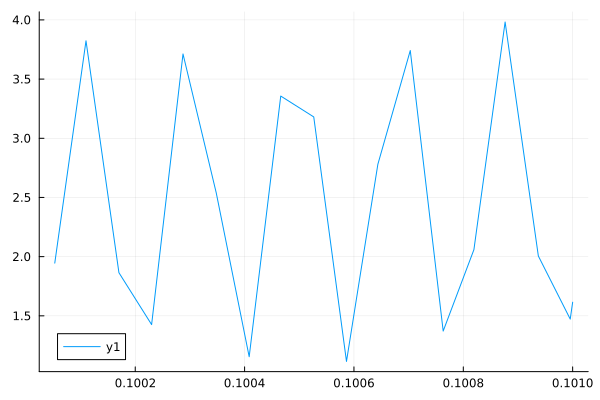

In [200]:
aOI = 5
axis = 8
sol =vcat(ans[aOI][2]...)
plot(ans[aOI][1],sol[:, axis]/kb*1e6 )#.- minimum(hcat(Ans[aOI][2]...)[axis, 2:end]/h ))


In [305]:
rampFuncLin(t, R_time) = t > R_time ? 10 : 10*t/R_time
rampFuncConst(t, R_time) = 0

rampFuncConst (generic function with 1 method)

In [38]:
Ans = simulateSanity(initCond[1:10])

10-element Vector{Any}:
 Vector[[0.0, 2.0e-7, 2.2e-6, 2.2199999999999998e-5, 9.614313643620468e-5, 0.00020976651292390323, 0.00034686176794711146, 0.0005222064239454568, 0.0007313829303389816, 0.0009747118675091258  …  0.01700699441599779, 0.017377603269389665, 0.017752300689938372, 0.018099392543500247, 0.018471150222287475, 0.018843683595807688, 0.019191849915691225, 0.019563455262270203, 0.019936227112745078, 0.02], [[7.717777255442267e-7, 2.2104438071897067e-5, -2.4198083145529647e-6, 0.00012908813447347624, -0.0008676566063303088, 0.004159376792233062, 0.0], [7.718034141816625e-7, 2.2104264515362034e-5, -2.4189761403123268e-6, 0.0001277982310563547, -0.0008679087496151078, 0.004162365392940798, 1.9080021590932354e-30], [7.720461096216493e-7, 2.2102526175132636e-5, -2.4106215744959585e-6, 0.00011489636482831679, -0.000870432045042714, 0.004192178212602732, 1.9343977789426657e-30], [7.730523360839866e-7, 2.2084863879395377e-5, -2.323848797670125e-6, -1.4319256530213519e-5, -0.000895

In [59]:
1/(abs(4*Potential(0, 0, -7.5e-6, [0.0, 10e6, 0.0, 0.0])/(moleculeMass*7e-6^2)))^(1/2)*4

0.0010620965217627973

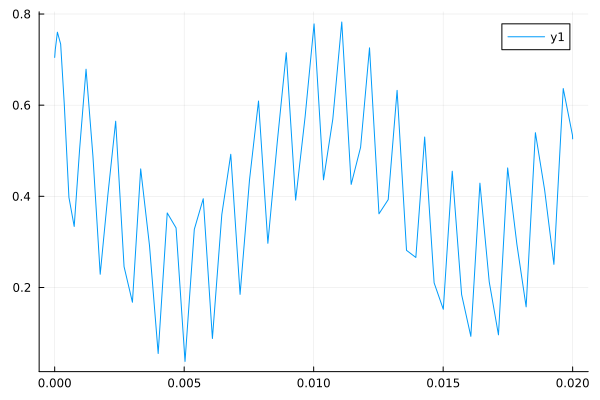

In [49]:
aOI = 3
axis = 7
plot(Ans[aOI][1][2:end],hcat(Ans[aOI][2]...)[axis, 2:end]/kb*1e6 )#.- minimum(hcat(Ans[aOI][2]...)[axis, 2:end]/h ))


In [519]:
5.53e-5 * 1e6 * h *1e-4*(30e7)/h

1.6590000000000002e6

In [ ]:
plot

In [21]:
simulate(initCond, 1e7/1e-6)

1.4057730249200258e-28

In [59]:
tramp = [1e-6,  2e-6, 10e-6, 20e-6, 25e-6, 40e-6,   50e-6]#, 100e-6, 200e-6,  500e-6, 1e-3, 5e-3,  10e-3]
#tramp = [1e-3, 10e-3, 30e-3, 70e-3, 100e-3, 1]

7-element Vector{Float64}:
 1.0e-6
 2.0e-6
 1.0e-5
 2.0e-5
 2.5e-5
 4.0e-5
 5.0e-5

10


TaskFailedException: TaskFailedException

    nested task error: Non-concrete element type inside of an `Array` detected.
    Arrays with non-concrete element types, such as
    `Array{Union{Float32,Float64}}`, are not supported by the
    differential equation solvers. Anyways, this is bad for
    performance so you don't want to be doing this!
    
    If this was a mistake, promote the element types to be
    all the same. If this was intentional, for example,
    using Unitful.jl with different unit values, then use
    an array type which has fast broadcast support for
    heterogeneous values such as the ArrayPartition
    from RecursiveArrayTools.jl. For example:
    
    ```julia
    using RecursiveArrayTools
    x = ArrayPartition([1.0,2.0],[1f0,2f0])
    y = ArrayPartition([3.0,4.0],[3f0,4f0])
    x .+ y # fast, stable, and usable as u0 into DiffEq!
    ```
    
    Element type:
    Any
    Stacktrace:
     [1] solve_call(_prob::ODEProblem{Vector{Any}, Tuple{Float64, Float64

In [60]:
heat1 = [simulate(initCond[1:10], 1e7/t_i, Fend = 10) for t_i in tramp]
#heat2 = [simulate(initCond, 1e7/t_i, Fend = 30) for t_i in tramp]

200


200


200


200


200


200


200


7-element Vector{Vector{Vector{Float64}}}:
 [[-2.474811748150432e-6, -9.307901209808733e-6, 1.1269600329458528e-5, -0.0060484262593407615, -0.008686480177936901, 0.003775317565379019], [-1.2184265218501956e-6, 1.5127798877268277e-6, 4.916035323529751e-6, 0.028631122006194182, -0.008037390920270608, 0.033571262567337286], [-8.920738751504671e-7, 5.0062560638170905e-6, -4.704390198149877e-6, -0.0013061243456154094, -0.0013811963900748363, 0.0007053952957906121], [-2.8349667341550716e-6, 8.571599199289044e-6, 1.0662520433661885e-5, 0.006033515740291234, -0.01086599008147577, -0.02205303624395336], [-1.8985495194064103e-6, 5.646898305677024e-6, -1.1347858236554219e-6, -0.0031439076122319397, 0.004796727689042711, 0.0030094329134625723], [-3.205844453638063e-7, 4.3892020860042136e-6, -1.1335082138421508e-5, 0.004327078044301279, -0.0010343945569484894, 0.024658667720835845], [1.452201425625155e-6, 1.727709796656866e-5, -8.42725996951849e-6, 0.02720718774686244, -0.006241508268917164, -0.041

In [79]:
f = Figure()
hist(f[1, 1], vec(hcat(heat1[end]...)'[:, 3]), bins = 20)

f

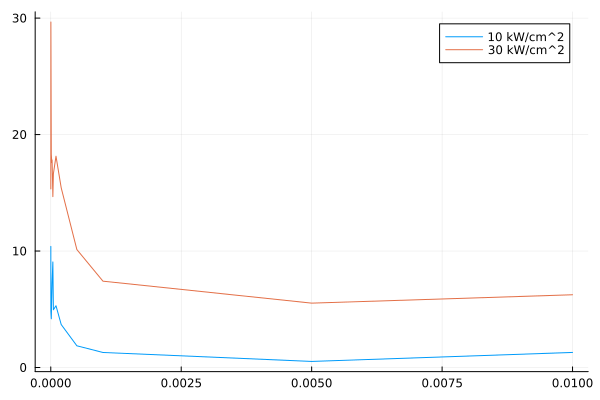

In [73]:
plot(tramp, heat1/kb*1e6, label = "10 kW/cm^2")
plot!(tramp, heat2/kb*1e6, label ="30 kW/cm^2")

In [578]:
heat/kb*1e6

13-element Vector{Float64}:
 28.8136390008307
 34.1222516883108
 16.21724166492507
 20.12568240039799
 11.539451675945694
 13.878169433480434
 13.87342219839703
 11.406397121583666
  9.222286930755219
  6.567080741693694
  6.43906703280589
  7.256999751250675
  8.01807465679287